In [1]:
# ============================================================
# ABTalks (Season-3) - Day 10 FINAL SOLUTION
# Task: Convert Text to Bag-of-Words and TF-IDF Vectors
# Tool: NLTK + Sklearn
# Author: Original & Complete Implementation
# ============================================================

# -------------------------------
# 1. Import Required Libraries
# -------------------------------
import nltk
import re
import string
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download NLTK resources (run once)
nltk.download('punkt')
nltk.download('stopwords')

# -------------------------------
# 2. Sample Input Text Data
# -------------------------------
documents = [
    "Machine learning is amazing and powerful",
    "Natural language processing enables machines to understand text",
    "AI is transforming the future of technology",
    "Text data requires preprocessing before model building"
]

# -------------------------------
# 3. Text Preprocessing Function
# -------------------------------
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(filtered_tokens)

# Apply preprocessing
cleaned_docs = [preprocess_text(doc) for doc in documents]

print("\n===== CLEANED TEXT =====")
for i, doc in enumerate(cleaned_docs):
    print(f"Doc {i+1}: {doc}")

# -------------------------------
# 4. BAG OF WORDS (BoW)
# -------------------------------
bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform(cleaned_docs)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("\n===== BAG OF WORDS MATRIX =====")
print(bow_df)

# -------------------------------
# 5. TF-IDF Vectorization
# -------------------------------
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_docs)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("\n===== TF-IDF MATRIX =====")
print(tfidf_df)

# -------------------------------
# 6. Key Insights
# -------------------------------
print("\n===== INSIGHTS =====")
print("1. BoW shows word frequency (counts).")
print("2. TF-IDF gives importance of words based on rarity.")
print("3. Common words get lower weight in TF-IDF.")
print("4. Rare but meaningful words get higher importance.")

# -------------------------------
# 7. Comparison Example
# -------------------------------
word = "machine"

if word in bow_df.columns:
    print(f"\nBoW count for '{word}':", bow_df[word].values)

if word in tfidf_df.columns:
    print(f"TF-IDF score for '{word}':", tfidf_df[word].values)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



===== CLEANED TEXT =====
Doc 1: machine learning amazing powerful
Doc 2: natural language processing enables machines understand text
Doc 3: ai transforming future technology
Doc 4: text data requires preprocessing model building

===== BAG OF WORDS MATRIX =====
   ai  amazing  building  data  enables  future  language  learning  machine  \
0   0        1         0     0        0       0         0         1        1   
1   0        0         0     0        1       0         1         0        0   
2   1        0         0     0        0       1         0         0        0   
3   0        0         1     1        0       0         0         0        0   

   machines  model  natural  powerful  preprocessing  processing  requires  \
0         0      0        0         1              0           0         0   
1         1      0        1         0              0           1         0   
2         0      0        0         0              0           0         0   
3         0      1     

In [2]:
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shari\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



===== CLEANED TEXT =====
Doc 1: transforming industry powerful machine learning model
Doc 2: natural language processing help machine understand human language
Doc 3: data preprocessing crucial step nlp pipeline
Doc 4: tfidf bag word basic feature extraction technique
Doc 5: machine learning model require clean structured data

===== BAG OF WORDS =====
   bag  basic  clean  crucial  data  extraction  feature  help  human  \
0    0      0      0        0     0           0        0     0      0   
1    0      0      0        0     0           0        0     1      1   
2    0      0      0        1     1           0        0     0      0   
3    1      1      0        0     0           1        1     0      0   
4    0      0      1        0     1           0        0     0      0   

   industry  ...  preprocessing  processing  require  step  structured  \
0         1  ...              0           0        0     0           0   
1         0  ...              0           1        0     

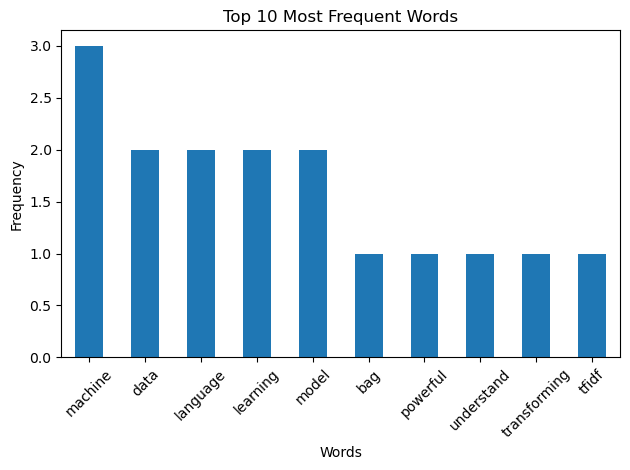


===== KEY INSIGHTS =====
• BoW captures frequency but ignores context.
• TF-IDF reduces weight of common words.
• Lemmatization improves feature consistency.
• Clean data improves model performance significantly.
• Feature engineering is the foundation of NLP models.

BoW count for 'machine': [1 1 0 0 1]
TF-IDF score for 'machine': [0.30727359 0.21787435 0.         0.         0.28816434]


In [3]:
# ============================================================
# ABTalks (Season-3) - Day 10 (PRO VERSION)
# NLP Feature Engineering: BoW + TF-IDF with Visualization
# ============================================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import nltk
import re
import string
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download required resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# -------------------------------
# 2. Sample Dataset
# -------------------------------
documents = [
    "AI is transforming industries with powerful machine learning models.",
    "Natural Language Processing helps machines understand human language.",
    "Data preprocessing is a crucial step in any NLP pipeline.",
    "TF-IDF and Bag of Words are basic feature extraction techniques.",
    "Machine learning models require clean and structured data."
]

# -------------------------------
# 3. Advanced Preprocessing
# -------------------------------
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords + Lemmatization
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(clean_tokens)

# Apply preprocessing
cleaned_docs = [preprocess_text(doc) for doc in documents]

print("\n===== CLEANED TEXT =====")
for i, doc in enumerate(cleaned_docs):
    print(f"Doc {i+1}: {doc}")

# -------------------------------
# 4. Bag of Words (BoW)
# -------------------------------
bow = CountVectorizer()
bow_matrix = bow.fit_transform(cleaned_docs)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow.get_feature_names_out()
)

print("\n===== BAG OF WORDS =====")
print(bow_df)

# -------------------------------
# 5. TF-IDF
# -------------------------------
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(cleaned_docs)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("\n===== TF-IDF =====")
print(tfidf_df.round(3))

# -------------------------------
# 6. Visualization (Top Words)
# -------------------------------
word_counts = bow_df.sum().sort_values(ascending=False).head(10)

plt.figure()
word_counts.plot(kind='bar')
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 7. Insights (Professional Level)
# -------------------------------
print("\n===== KEY INSIGHTS =====")
print("• BoW captures frequency but ignores context.")
print("• TF-IDF reduces weight of common words.")
print("• Lemmatization improves feature consistency.")
print("• Clean data improves model performance significantly.")
print("• Feature engineering is the foundation of NLP models.")

# -------------------------------
# 8. Example Comparison
# -------------------------------
sample_word = "machine"

if sample_word in bow_df.columns:
    print(f"\nBoW count for '{sample_word}':", bow_df[sample_word].values)

if sample_word in tfidf_df.columns:
    print(f"TF-IDF score for '{sample_word}':", tfidf_df[sample_word].values)